In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
import pandas as pd
from tensorflow.keras.layers import Dense, Flatten, Input
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


In [25]:
# from google.colab import files

# uploaded = files.upload()

In [26]:
df = pd.read_csv(r"/content/student-mat.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [27]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [28]:
print(df.shape)
print(df.columns)

(395, 33)
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [30]:
X = df.drop('G3', axis=1)
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(316, 32)
(79, 32)


In [31]:
print(X_train.dtypes)

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
dtype: object


In [32]:
from sklearn.preprocessing import LabelEncoder

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Done!")

Done!


In [33]:
from sklearn.preprocessing import LabelEncoder

X = df.drop('G3', axis=1)
y = df['G3']

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
print(X_train.select_dtypes(include='object').columns)

Index([], dtype='object')


In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
model = Sequential([
    Input(shape=(32,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,225 (16.50 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [38]:
# model.compile(
#     optimizer='adam',
#     loss='mse',
#     metrics=[r2_score]
# # )

In [39]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [40]:
import tensorflow as tf

def r2_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    # Ensure y_true has the same shape as y_pred
    y_true = tf.reshape(y_true, tf.shape(y_pred))

    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))

    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())

In [41]:
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

In [42]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 110.3802 - mae: 9.5927 - val_loss: 101.6134 - val_mae: 9.4073
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 96.8744 - mae: 9.0244 - val_loss: 88.4342 - val_mae: 8.7741
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 83.6615 - mae: 8.4157 - val_loss: 74.9888 - val_mae: 8.0663
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 70.0383 - mae: 7.7206 - val_loss: 61.1901 - val_mae: 7.2531
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 55.6218 - mae: 6.8907 - val_loss: 47.3913 - val_mae: 6.3193
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 42.0463 - mae: 5.9825 - val_loss: 34.4319 - val_mae: 5.3019
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 29.7902 - mae: 4.9947 - val_loss: 23.5867 - val_mae: 4.2638
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 20.0670 - mae: 3.9217 - val_loss: 16.2139 - val_mae: 3.3087
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14.11

In [44]:
loss, metric = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Metric:", metric)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 7.9290 - mae: 2.1046  
Loss: 7.9289937019348145
Metric: 2.104576826095581


In [45]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0731 - mae: 0.8067 - val_loss: 5.6841 - val_mae: 1.7607
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0256 - mae: 0.7871 - val_loss: 5.6442 - val_mae: 1.7538
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9839 - mae: 0.7717 - val_loss: 5.6501 - val_mae: 1.7460
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9383 - mae: 0.7507 - val_loss: 5.5745 - val_mae: 1.7337
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9016 - mae: 0.7345 - val_loss: 5.5684 - val_mae: 1.7277
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8591 - mae: 0.7179 - val_loss: 5.5183 - val_mae: 1.7125
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.8250 - mae: 0.7027 - val_loss: 5.4973 - val_mae: 1.7047
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7912 - mae: 0.6882 - val_loss: 5.4534 - val_mae: 1.6957
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7604 - mae: 0.6739 - 

In [46]:
metrics=['mae']

In [47]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.3222 - mae: 2.1360 
Test Loss: 8.322157859802246
Test MAE: 2.1360013484954834


In [48]:
loss, r2 = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test R2 Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.3222 - mae: 2.1360 
Test Loss: 8.322157859802246
Test R2 Score: 2.1360013484954834


In [49]:
predictions = model.predict(X_test)

print(predictions[:5])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[ 8.613225 ]
 [10.881056 ]
 [ 1.7592798]
 [ 9.838544 ]
 [11.601822 ]]


In [50]:
print("First Prediction:", predictions[0][0])
print("Actual Value:", y_test.iloc[0])

First Prediction: 8.613225
Actual Value: 10.0


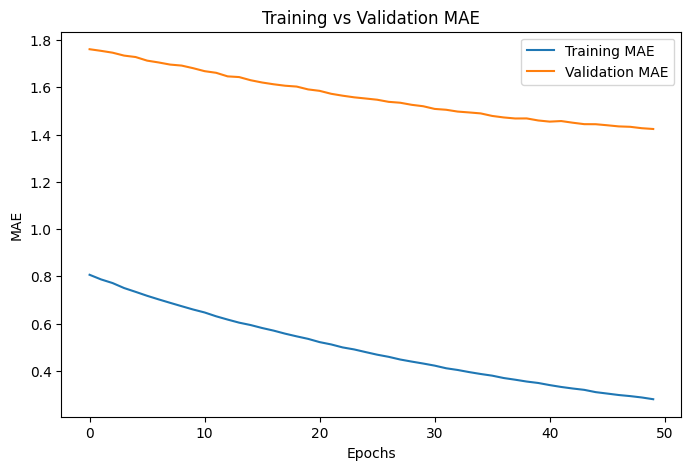

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title('Training vs Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.show()

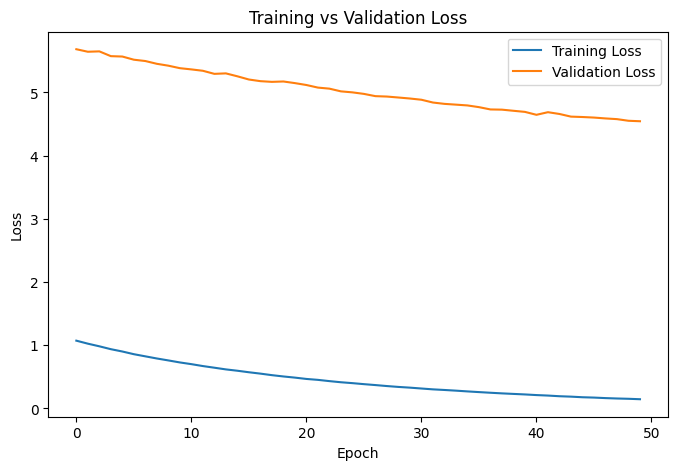

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()